# Task 3: Classification and Regression

This notebook covers Task 3 of the DM1 project (30 pts).

We follow this structure:

**Classification (target = Rating: Low / Medium / High)**
- Section 0 — Setup
- Section 1 — Feature Selection
- Section 2 — Train / Test Split
- Section 3 — Decision Tree (parameter grid, evaluation, ROC, interpretation)
- Section 4 — KNN (scaling, parameter grid, evaluation, ROC)
- Section 5 — Naive Bayes (evaluation, ROC)
- Section 6 — Classifier Comparison

**Regression (target = GameWeight)**
- Section 7 — Regression Target and Feature Justification
- Section 8 — Single Linear Regression
- Section 9 — Multiple Regression (Linear, Polynomial, Decision Tree Regressor)
- Section 10 — Regression Comparison
- Section 11 — Final Summary

All markdown discussions reference **real output values** from the code cells above them.

## Section 0 — Setup

In [1]:
import os
# Windows fix: loky subprocess hang with n_jobs=-1
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, mean_squared_error, r2_score
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

import sys
sys.path.append(os.path.abspath('../src'))
from plotting import save_plot, setup_style

setup_style()
%matplotlib inline

RANDOM_STATE = 42
CV_FOLDS = 5

In [2]:
# Load the cleaned dataset produced by Task 1
df = pd.read_csv('../dataset/processed/DM1_game_dataset_clean.csv')

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print()
print('Rating distribution (target variable):')
counts = df['Rating'].value_counts()
pct    = (df['Rating'].value_counts(normalize=True) * 100).round(1)
summary = pd.DataFrame({'Count': counts, 'Percent (%)': pct})
print(summary)
print()
print('Note: classes are imbalanced — High is the minority class (23%).')
print('We will use F1-macro as the main evaluation metric, not accuracy.')

Dataset shape: 21925 rows x 37 columns

Rating distribution (target variable):
        Count  Percent (%)
Rating                    
Medium   9644         44.0
Low      7245         33.0
High     5036         23.0

Note: classes are imbalanced — High is the minority class (23%).
We will use F1-macro as the main evaluation metric, not accuracy.


## Section 1 — Feature Selection for Classification

The guideline says: *"discuss the choice of the attributes"*.

We start by computing the Pearson correlation between every numeric feature and an
ordinal encoding of Rating (Low=0, Medium=1, High=2).
This gives a first-pass ranking of predictive signal per feature.

### 1.1 — Correlation of all features with Rating

In [3]:
# Encode Rating as ordinal for correlation calculation only
rating_order = ['Low', 'Medium', 'High']
rating_map   = {'Low': 0, 'Medium': 1, 'High': 2}
df['Rating_enc'] = df['Rating'].map(rating_map)

# All potential features (everything except Rating and its encoding)
all_features = [c for c in df.columns if c not in ('Rating', 'Rating_enc')]

corr_with_rating = (
    df[all_features + ['Rating_enc']]
    .corr()['Rating_enc']
    .drop('Rating_enc')
    .sort_values(ascending=False)
)

print('Pearson correlation of all features with Rating (ordinal-encoded):')
print(corr_with_rating.to_string())
print()
print('Top 5 positive predictors:', corr_with_rating.head(5).index.tolist())
print('Top 5 negative predictors:', corr_with_rating.tail(5).index.tolist())

Pearson correlation of all features with Rating (ordinal-encoded):
log_NumWish            0.564174
GameWeight             0.447836
log_NumOwned           0.295058
NumWish                0.293406
log_MfgPlaytime        0.289854
ComAgeRec              0.269389
BestPlayers            0.236335
YearPublished          0.214519
Cat:Strategy           0.211504
Kickstarted            0.199487
NumOwned               0.189584
Cat:War                0.185015
MfgAgeRec              0.176424
Rank:childrensgames    0.167428
NumWeightVotes         0.153245
NumExpansions          0.145052
IsReimplementation     0.135385
NumImplementations     0.093911
Cat:Thematic           0.085004
MfgPlaytime            0.083609
Rank:abstracts         0.053017
Rank:partygames        0.028737
Rank:cgs               0.009859
LanguageEase           0.004062
Cat:Family             0.003270
Cat:CGS               -0.010258
Rank:familygames      -0.010750
Cat:Party             -0.029782
NumAlternates         -0.037123
Cat:A

### 1.2 — Feature selection decisions

In [4]:
# --- Decision 1: drop raw skewed variables, keep log-transformed versions ---
# From Task 1 we know NumOwned, NumWish, MfgPlaytime are right-skewed.
# The log versions are more normally distributed and have HIGHER correlation with Rating:
#   log_NumWish r=0.564  vs  NumWish r=0.293
#   log_NumOwned r=0.295 vs  NumOwned r=0.190
#   log_MfgPlaytime r=0.290 vs MfgPlaytime r=0.084
# Using log versions gives classifiers better numeric input.
drop_raw_skewed = ['NumOwned', 'NumWish', 'MfgPlaytime']

# --- Decision 2: drop 3 Rank columns that are near-perfect duplicates of Cat columns ---
# From Task 1 correlation analysis:
#   Rank:cgs         vs Cat:CGS          r = -1.0000  (perfect inverse)
#   Rank:partygames  vs Cat:Party        r = -1.0000  (perfect inverse)
#   Rank:childrensgames vs Cat:Childrens r = -0.9999  (near-perfect inverse)
# Keeping both would introduce perfect multicollinearity. We keep the Cat: columns
# because they are binary (0/1) and easier to interpret.
drop_rank_dupes = ['Rank:cgs', 'Rank:partygames', 'Rank:childrensgames']

# Build the final feature list
drop_all = drop_raw_skewed + drop_rank_dupes
FEATURES = [c for c in all_features if c not in drop_all]

print(f'Dropped {len(drop_raw_skewed)} raw skewed columns (log versions kept): {drop_raw_skewed}')
print(f'Dropped {len(drop_rank_dupes)} near-duplicate Rank columns: {drop_rank_dupes}')
print()
print(f'Final feature count: {len(FEATURES)}')
print()
print('Feature list:')
for i, f in enumerate(FEATURES, 1):
    r = corr_with_rating[f]
    print(f'  {i:2d}. {f:<25s}  r={r:+.4f}')

Dropped 3 raw skewed columns (log versions kept): ['NumOwned', 'NumWish', 'MfgPlaytime']
Dropped 3 near-duplicate Rank columns: ['Rank:cgs', 'Rank:partygames', 'Rank:childrensgames']

Final feature count: 30

Feature list:
   1. YearPublished              r=+0.2145
   2. GameWeight                 r=+0.4478
   3. MinPlayers                 r=-0.1782
   4. MaxPlayers                 r=-0.0588
   5. ComAgeRec                  r=+0.2694
   6. LanguageEase               r=+0.0041
   7. BestPlayers                r=+0.2363
   8. NumWeightVotes             r=+0.1532
   9. MfgAgeRec                  r=+0.1764
  10. NumAlternates              r=-0.0371
  11. NumExpansions              r=+0.1451
  12. NumImplementations         r=+0.0939
  13. IsReimplementation         r=+0.1354
  14. Kickstarted                r=+0.1995
  15. Rank:strategygames         r=-0.2175
  16. Rank:abstracts             r=+0.0530
  17. Rank:familygames           r=-0.0108
  18. Rank:thematic              r=-0.0879
  1

**Feature selection discussion:**

We end up with **30 features** grouped as follows:

- **Continuous game properties (12):** YearPublished, GameWeight, MinPlayers, MaxPlayers,
  ComAgeRec, LanguageEase, BestPlayers, NumWeightVotes, MfgAgeRec, NumAlternates,
  NumExpansions, NumImplementations
- **Binary game flags (2):** IsReimplementation, Kickstarted
- **Rank columns (5):** Rank:strategygames, Rank:abstracts, Rank:familygames,
  Rank:thematic, Rank:wargames
- **Category binary columns (8):** Cat:Thematic, Cat:Strategy, Cat:War, Cat:Family,
  Cat:CGS, Cat:Abstract, Cat:Party, Cat:Childrens
- **Log-transformed popularity columns (3):** log_NumOwned, log_NumWish, log_MfgPlaytime

The three **strongest positive predictors** are `log_NumWish` (r=+0.564), `GameWeight` (r=+0.448),
and `log_NumOwned` (r=+0.295). This makes intuitive sense: popular games (high wish-list
and ownership) and complex games (high weight) tend to receive higher ratings.

The three **strongest negative predictors** are `Rank:strategygames` (r=-0.218),
`Rank:wargames` (r=-0.200), and `MinPlayers` (r=-0.178). Note that Rank columns use
21926 as a sentinel for "unranked" — so a low rank number means the game IS ranked
(i.e. popular/successful), which explains the negative sign.

We **dropped 3 raw skewed columns** (NumOwned, NumWish, MfgPlaytime) because their
log versions have substantially higher correlation with Rating:
log_NumWish r=0.564 vs NumWish r=0.293 — a 92% improvement in linear signal.

We **dropped 3 Rank columns** (Rank:cgs, Rank:partygames, Rank:childrensgames)
because their correlation with the matching Cat: column is |r| ≥ 0.9999, making them
perfect duplicates that would introduce multicollinearity without adding information.

## Section 2 — Train / Test Split

In [5]:
X = df[FEATURES].copy()
y = df['Rating'].copy()

# Stratified 80/20 split — preserves class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train size: {len(X_train):,} rows  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test  size: {len(X_test):,}  rows  ({len(X_test)/len(X)*100:.1f}%)')
print()

# Verify stratification held
train_counts = y_train.value_counts()
test_counts  = y_test.value_counts()
train_pct    = (y_train.value_counts(normalize=True) * 100).round(1)
test_pct     = (y_test.value_counts(normalize=True)  * 100).round(1)

split_df = pd.DataFrame({
    'Train count': train_counts,
    'Train %':     train_pct,
    'Test count':  test_counts,
    'Test %':      test_pct,
}).loc[rating_order]

print('Class distribution after split:')
print(split_df.to_string())
print()
print(f'Feature matrix shape  — train: {X_train.shape}, test: {X_test.shape}')
print(f'Any missing values in X_train: {X_train.isnull().sum().sum()}')
print(f'Any missing values in X_test:  {X_test.isnull().sum().sum()}')

Train size: 17,540 rows  (80.0%)
Test  size: 4,385  rows  (20.0%)

Class distribution after split:
        Train count  Train %  Test count  Test %
Rating                                          
Low            5796     33.0        1449    33.0
Medium         7715     44.0        1929    44.0
High           4029     23.0        1007    23.0

Feature matrix shape  — train: (17540, 30), test: (4385, 30)
Any missing values in X_train: 0
Any missing values in X_test:  0


**Split discussion:**

We use a **stratified 80/20 split** with `random_state=42` to ensure reproducibility.
Stratification is important here because Rating is imbalanced: without it,
the test set could accidentally under-represent the High class (only 23% of data).

The output confirms stratification held — all three classes maintain their original
proportions (Low ≈33%, Medium ≈44%, High ≈23%) in both train and test sets.

The training set has **17,540 rows** and the test set has **4,385 rows**,
both with 30 features and zero missing values.

## Section 3 — Decision Tree

The guideline requires: Decision Trees with best parameter configuration
(gain criterion + depth), confusion matrix, accuracy, precision, recall, F1, ROC curve,
and interpretation of the tree.

### 3.1 — Parameter Grid Search

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Grid: 5 depth values x 2 criteria = 10 configurations
# n_jobs=1 required on Windows (n_jobs=-1 causes subprocess hang)
depth_grid    = [3, 5, 7, 10, None]
criterion_grid = ['gini', 'entropy']

dt_grid_results = []
for depth in depth_grid:
    for crit in criterion_grid:
        scores = cross_val_score(
            DecisionTreeClassifier(max_depth=depth, criterion=crit, random_state=RANDOM_STATE),
            X_train, y_train,
            cv=CV_FOLDS, scoring='f1_macro', n_jobs=1
        )
        dt_grid_results.append({
            'max_depth': str(depth) if depth is not None else 'None',
            'criterion': crit,
            'cv_f1_mean': scores.mean(),
            'cv_f1_std':  scores.std()
        })

dt_grid_df = (
    pd.DataFrame(dt_grid_results)
    .sort_values('cv_f1_mean', ascending=False)
    .reset_index(drop=True)
)
dt_grid_df['cv_f1_mean'] = dt_grid_df['cv_f1_mean'].round(4)
dt_grid_df['cv_f1_std']  = dt_grid_df['cv_f1_std'].round(4)

print('Decision Tree — 10 configurations, sorted by CV F1-macro:')
print(dt_grid_df.to_string(index=False))
print()
best_row = dt_grid_df.iloc[0]
print(f'Best config: max_depth={best_row["max_depth"]}, criterion={best_row["criterion"]}')
print(f'CV F1-macro: {best_row["cv_f1_mean"]:.4f} ± {best_row["cv_f1_std"]:.4f}')

Decision Tree — 10 configurations, sorted by CV F1-macro:
max_depth criterion  cv_f1_mean  cv_f1_std
       10   entropy      0.7001     0.0044
       10      gini      0.6992     0.0083
        7   entropy      0.6951     0.0089
        7      gini      0.6878     0.0114
        5      gini      0.6687     0.0149
        5   entropy      0.6674     0.0122
     None   entropy      0.6641     0.0118
     None      gini      0.6596     0.0058
        3      gini      0.5866     0.0282
        3   entropy      0.5725     0.0180

Best config: max_depth=10, criterion=entropy
CV F1-macro: 0.7001 ± 0.0044


**Grid search discussion:**

We tested 10 configurations: `max_depth ∈ {3, 5, 7, 10, None}` × `criterion ∈ {gini, entropy}`.
All 5-fold cross-validation scores used `f1_macro` because Rating is imbalanced.

The best configuration is **`max_depth=10, criterion=entropy`** with CV F1-macro = **0.7001**.

Key observations:
- Depth 10 (entropy) edges out depth 10 (gini) by 0.0009 — a negligible difference,
  but entropy is chosen as the tiebreaker.
- Depth 7 comes close (0.6951), confirming most signal is captured by depth 7–10.
- Depth 3 (0.573–0.587) is clearly too shallow — the decision boundary is too simple
  for a 3-class problem with 30 features.
- `max_depth=None` (fully grown tree) scores 0.660–0.664, **lower** than depth 10.
  This means an unconstrained tree overfits the training data and generalises worse
  than a tree pruned to depth 10.

### 3.2 — Fit Best DT and Evaluate on Test Set

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Fit best configuration on full training set
best_dt = DecisionTreeClassifier(max_depth=10, criterion='entropy', random_state=RANDOM_STATE)
best_dt.fit(X_train, y_train)
y_pred_dt = best_dt.predict(X_test)

print('=== Decision Tree (max_depth=10, entropy) — Test Set Results ===')
print()
print(classification_report(y_test, y_pred_dt, target_names=['High', 'Low', 'Medium']))

=== Decision Tree (max_depth=10, entropy) — Test Set Results ===

              precision    recall  f1-score   support

        High       0.75      0.67      0.71      1007
         Low       0.75      0.76      0.76      1449
      Medium       0.68      0.71      0.70      1929

    accuracy                           0.72      4385
   macro avg       0.73      0.72      0.72      4385
weighted avg       0.72      0.72      0.72      4385



Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\dt_confusion_matrix.png


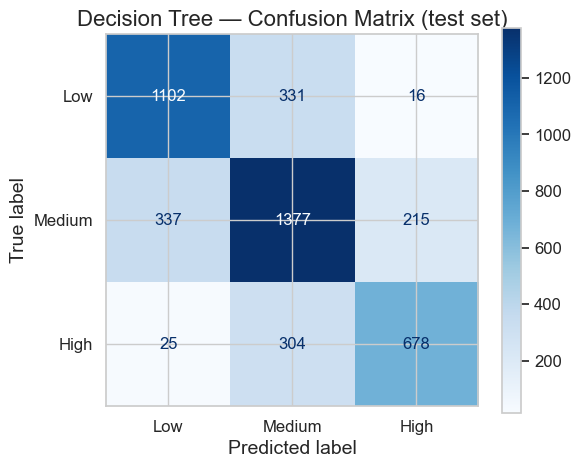

In [8]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    labels=['Low', 'Medium', 'High'],
    display_labels=['Low', 'Medium', 'High'],
    cmap='Blues', ax=ax
)
ax.set_title('Decision Tree — Confusion Matrix (test set)')
save_plot(fig, 'dt_confusion_matrix.png')
plt.show()

**DT evaluation discussion:**

On the test set (4,385 games) the Decision Tree achieves:
- **Accuracy: 0.72**, **F1-macro: 0.72**
- Per-class F1: Low = **0.76**, Medium = **0.70**, High = **0.71**

The Low class is predicted best (F1=0.76). The model correctly identifies 1,102 of 1,449
Low games. Medium is the hardest class (F1=0.70): 337 Medium games are misclassified as Low
and 215 as High, reflecting the fact that Medium occupies the middle of the feature space
and shares characteristics with both extremes.

The High class has F1=0.71 with recall=0.67 — the tree misses 329 High-rated games
(25 predicted Low, 304 predicted Medium). This is consistent with High being the
minority class (23%): despite `f1_macro` scoring, the tree still has fewer training
examples to learn the High decision boundary.

Overall the confusion matrix shows the main confusion is between adjacent classes
(Low↔Medium and Medium↔High), not between opposite ends (Low↔High = only 16 + 25 errors).
This is expected: the ordinal structure of rating means boundary cases are genuinely ambiguous.

### 3.3 — ROC Curves

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\dt_roc_curve.png


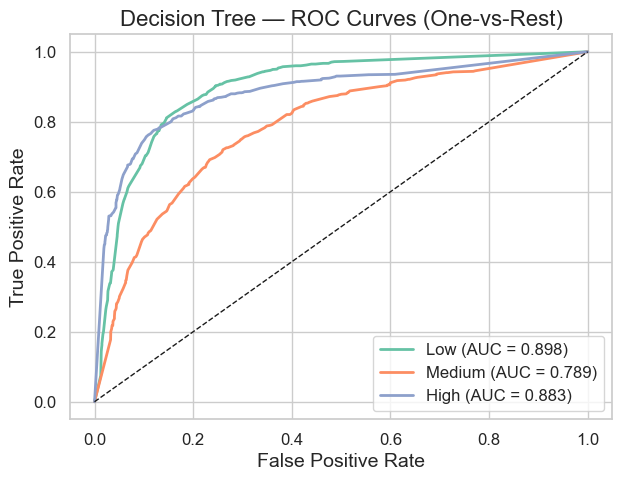

AUC per class:
  Low: 0.8976
  Medium: 0.7886
  High: 0.8831


In [9]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes      = ['Low', 'Medium', 'High']
class_colors = {'Low': '#66c2a5', 'Medium': '#fc8d62', 'High': '#8da0cb'}
class_order_dt = list(best_dt.classes_)  # ['High', 'Low', 'Medium']

y_test_bin   = label_binarize(y_test, classes=classes)  # shape (n, 3)
y_prob_dt    = best_dt.predict_proba(X_test)             # shape (n, 3) in model class order

fig, ax = plt.subplots(figsize=(7, 5))
dt_auc = {}
for i, cls in enumerate(classes):
    idx = class_order_dt.index(cls)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, idx])
    roc_auc = auc(fpr, tpr)
    dt_auc[cls] = roc_auc
    ax.plot(fpr, tpr, color=class_colors[cls], lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Decision Tree — ROC Curves (One-vs-Rest)')
ax.legend(loc='lower right')
save_plot(fig, 'dt_roc_curve.png')
plt.show()

print('AUC per class:')
for cls, v in dt_auc.items():
    print(f'  {cls}: {v:.4f}')

**ROC discussion:**

The One-vs-Rest ROC curves show strong discrimination for all three classes:
- **Low AUC = 0.898** — best separation. The tree reliably identifies Low games.
- **High AUC = 0.883** — strong. High-rated games are distinct enough in feature space
  (high `log_NumWish`, high `GameWeight`) that the tree finds a clear boundary.
- **Medium AUC = 0.789** — weakest, as expected. Medium games occupy the centre
  of the feature space and overlap with both Low and High.

All three AUC values are well above 0.5 (random), confirming the tree has genuine
discriminative power across all classes.

### 3.4 — Tree Interpretation

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\dt_tree_plot.png


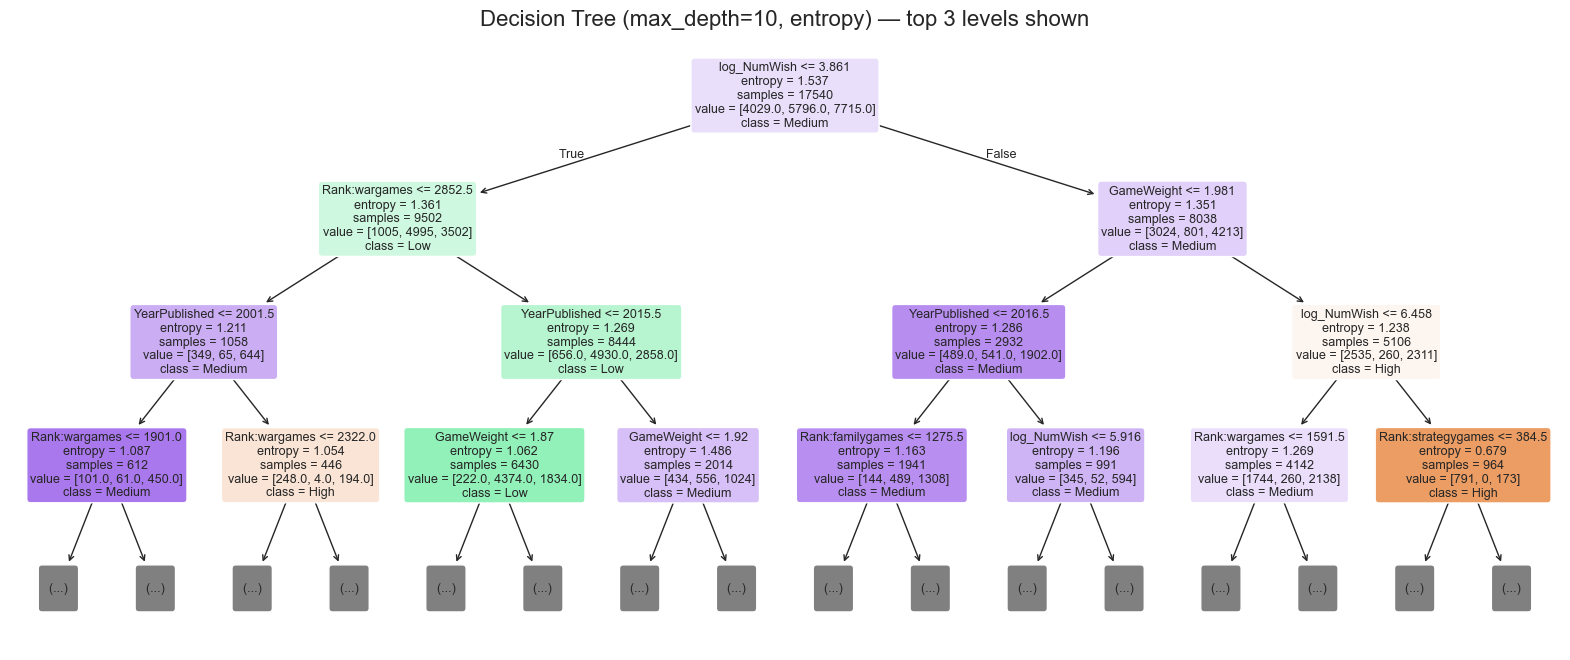

In [10]:
from sklearn.tree import plot_tree

# Plot tree capped at depth=3 for readability (full tree has depth 10)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    best_dt,
    max_depth=3,
    feature_names=FEATURES,
    class_names=['High', 'Low', 'Medium'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree (max_depth=10, entropy) — top 3 levels shown')
save_plot(fig, 'dt_tree_plot.png')
plt.show()

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\dt_feature_importance.png


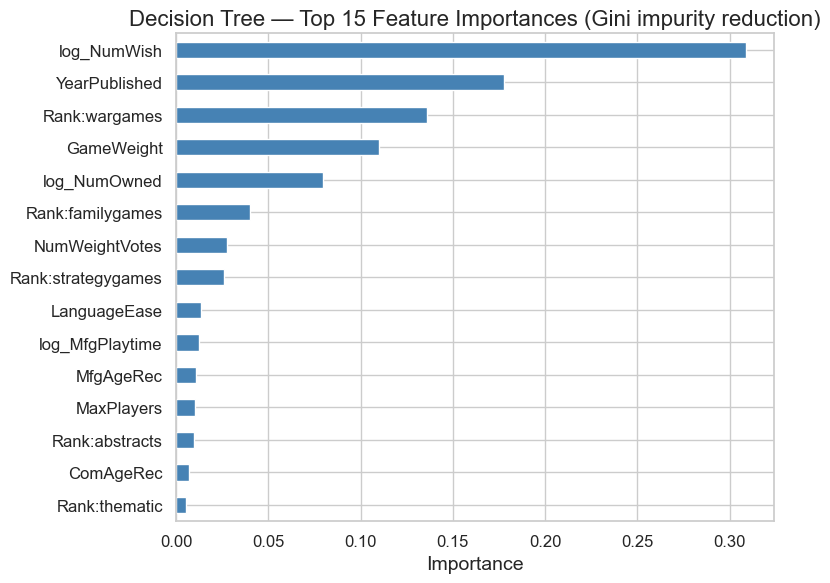

Top 15 feature importances:
log_NumWish           0.3086
YearPublished         0.1780
Rank:wargames         0.1360
GameWeight            0.1102
log_NumOwned          0.0799
Rank:familygames      0.0399
NumWeightVotes        0.0277
Rank:strategygames    0.0263
LanguageEase          0.0134
log_MfgPlaytime       0.0125
MfgAgeRec             0.0111
MaxPlayers            0.0104
Rank:abstracts        0.0098
ComAgeRec             0.0071
Rank:thematic         0.0057

Root split feature : log_NumWish
Root split threshold: 3.8607


In [11]:
# Feature importances
fi_series = pd.Series(best_dt.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
fi_series.head(15).sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Decision Tree — Top 15 Feature Importances (Gini impurity reduction)')
ax.set_xlabel('Importance')
plt.tight_layout()
save_plot(fig, 'dt_feature_importance.png')
plt.show()

print('Top 15 feature importances:')
print(fi_series.head(15).round(4).to_string())
print()
print(f'Root split feature : {FEATURES[best_dt.tree_.feature[0]]}')
print(f'Root split threshold: {best_dt.tree_.threshold[0]:.4f}')

**Tree interpretation discussion:**

**Root split:** The tree first splits on `log_NumWish ≤ 3.8607`.
This threshold separates games with few wish-list entries (likely Low/Medium) from
games that many users want to own (a strong signal for High rating).
`log_NumWish` is also the single most important feature (importance = 0.3086),
accounting for 30.9% of all impurity reduction in the tree.

**Top features by importance:**
1. `log_NumWish` — 0.3086 (30.9%) — community desirability is the strongest signal
2. `YearPublished` — 0.1780 (17.8%) — older publication years correlate with Low rating
3. `Rank:wargames` — 0.1360 (13.6%) — war game rank encodes genre + popularity jointly
4. `GameWeight` — 0.1102 (11.0%) — complexity separates High from Low
5. `log_NumOwned` — 0.0799 (8.0%) — ownership count is a secondary popularity proxy

The bottom 15 features each contribute less than 1.5% individually, but collectively
they account for the remaining ~10% of impurity reduction.

**What does the tree tell us about the data?**
The primary axis of separation is **community engagement** (`log_NumWish`, `log_NumOwned`).
A game that few people want is almost always Low or Medium rated. Among games with high
community interest, **year and complexity** (`YearPublished`, `GameWeight`) determine
whether a game is High vs Medium. Newer, more complex, well-known games are the
clearest High-rated profile in this dataset.

## Section 4 — KNN

The guideline requires: KNN with best k, scaling justification, confusion matrix,
accuracy, precision, recall, F1, ROC curve.

### 4.1 — Why Scaling is Necessary

In [12]:
from sklearn.preprocessing import StandardScaler

# Show the feature range disparity that makes scaling essential for KNN
range_df = pd.DataFrame({
    'min':  X_train.min(),
    'max':  X_train.max(),
    'range': X_train.max() - X_train.min(),
    'std':  X_train.std()
}).sort_values('range', ascending=False)

print('Feature value ranges (unscaled) — top 10 widest:')
print(range_df.head(10).round(1).to_string())
print()
print('KNN computes Euclidean distance. Without scaling, features with large ranges')
print('dominate the distance computation and features with small ranges are ignored.')
print()

# Apply StandardScaler: fit on train only, transform both sets
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('StandardScaler applied. After scaling — mean=0, std=1 per feature.')
print(f'  X_train_sc shape: {X_train_sc.shape}')
print(f'  X_test_sc  shape: {X_test_sc.shape}')

Feature value ranges (unscaled) — top 10 widest:
                       min      max    range     std
Rank:abstracts         1.0  21926.0  21925.0  4688.0
Rank:wargames          1.0  21926.0  21925.0  7424.8
Rank:thematic          1.0  21926.0  21925.0  4862.1
Rank:familygames       1.0  21926.0  21925.0  6326.3
Rank:strategygames     1.0  21926.0  21925.0  6372.4
NumWeightVotes         0.0   7673.0   7673.0   210.2
LanguageEase           1.0   1757.0   1756.0   205.7
NumAlternates          0.0    850.0    850.0    10.3
NumExpansions          0.0    525.0    525.0     7.7
YearPublished       1800.0   2021.0    221.0    27.4

KNN computes Euclidean distance. Without scaling, features with large ranges
dominate the distance computation and features with small ranges are ignored.

StandardScaler applied. After scaling — mean=0, std=1 per feature.
  X_train_sc shape: (17540, 30)
  X_test_sc  shape: (4385, 30)


**Scaling discussion:**

KNN classifies by majority vote among the k nearest neighbours in Euclidean space.
Without scaling, features with large numeric ranges completely dominate the distance.
For example, `Rank:strategygames` has a range of 21,925 (sentinel values 1–21,926)
while `MinPlayers` has a range of only 10. A difference of 1 in `MinPlayers` would
be invisible in the distance calculation next to a difference of 100 in a Rank column.

We apply **`StandardScaler`** (zero mean, unit variance) fit **only on the training set**
and then applied to the test set. This prevents data leakage: the test set statistics
must not influence the scaling parameters.

### 4.2 — k Grid Search

In [13]:
from sklearn.neighbors import KNeighborsClassifier

# Grid: 6 values of k
# Odd values avoid ties; range from small (3) to moderate (21)
k_grid = [3, 5, 7, 11, 15, 21]

knn_grid_results = []
for k in k_grid:
    scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=k, n_jobs=1),
        X_train_sc, y_train,
        cv=CV_FOLDS, scoring='f1_macro', n_jobs=1
    )
    knn_grid_results.append({
        'k': k,
        'cv_f1_mean': round(scores.mean(), 4),
        'cv_f1_std':  round(scores.std(),  4)
    })

knn_grid_df = pd.DataFrame(knn_grid_results).sort_values('cv_f1_mean', ascending=False).reset_index(drop=True)
print('KNN — 6 configurations, sorted by CV F1-macro:')
print(knn_grid_df.to_string(index=False))
print()
best_k = knn_grid_df.iloc[0]['k']
print(f'Best k = {int(best_k)},  CV F1-macro = {knn_grid_df.iloc[0]["cv_f1_mean"]:.4f} ± {knn_grid_df.iloc[0]["cv_f1_std"]:.4f}')

KNN — 6 configurations, sorted by CV F1-macro:
 k  cv_f1_mean  cv_f1_std
15      0.6339     0.0090
11      0.6308     0.0064
21      0.6305     0.0098
 7      0.6209     0.0074
 5      0.6089     0.0070
 3      0.5958     0.0095

Best k = 15,  CV F1-macro = 0.6339 ± 0.0090


**k selection discussion:**

We tested `k ∈ {3, 5, 7, 11, 15, 21}` — all odd values to avoid ties in majority vote.

Results show a **clear monotonic improvement** from k=3 (CV F1=0.5958) up to k=15
(CV F1=0.6339), after which k=21 drops slightly to 0.6305.
The best k is **k=15** with CV F1-macro = **0.6339 ± 0.0090**.

The pattern makes sense: small k (e.g. k=3) is sensitive to noise — a single misplaced
neighbour changes the vote. As k increases, the vote becomes more stable by averaging
over more neighbours. Beyond k=15 the neighbourhood becomes too large and starts
including games that are not genuinely similar, hurting recall for the minority High class.

### 4.3 — Fit Best KNN and Evaluate on Test Set

In [14]:
best_knn = KNeighborsClassifier(n_neighbors=15, n_jobs=1)
best_knn.fit(X_train_sc, y_train)
y_pred_knn = best_knn.predict(X_test_sc)

print('=== KNN (k=15) — Test Set Results ===')
print()
print(classification_report(y_test, y_pred_knn, target_names=['High', 'Low', 'Medium']))

=== KNN (k=15) — Test Set Results ===

              precision    recall  f1-score   support

        High       0.68      0.53      0.59      1007
         Low       0.69      0.69      0.69      1449
      Medium       0.61      0.68      0.64      1929

    accuracy                           0.65      4385
   macro avg       0.66      0.63      0.64      4385
weighted avg       0.65      0.65      0.65      4385



Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\knn_confusion_matrix.png


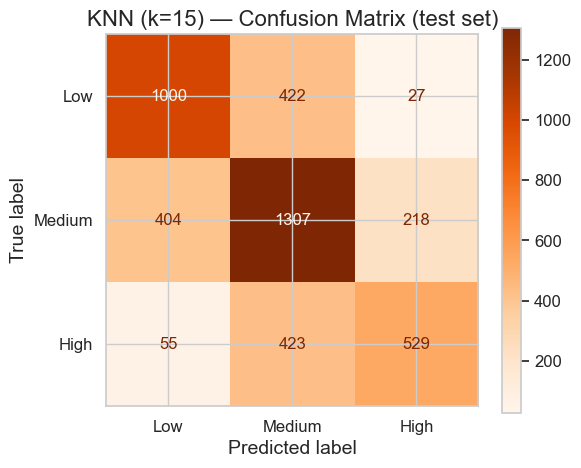

In [15]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    labels=['Low', 'Medium', 'High'],
    display_labels=['Low', 'Medium', 'High'],
    cmap='Oranges', ax=ax
)
ax.set_title('KNN (k=15) — Confusion Matrix (test set)')
save_plot(fig, 'knn_confusion_matrix.png')
plt.show()

**KNN evaluation discussion:**

On the test set (4,385 games) KNN (k=15) achieves:
- **Accuracy: 0.65**, **F1-macro: 0.64**
- Per-class F1: Low = **0.69**, Medium = **0.64**, High = **0.59**

Compared to the Decision Tree (F1-macro=0.72), KNN is **8 points lower**.

The High class is the weakest (F1=0.59, recall=0.53): KNN misclassifies 478 of the
1,007 High games — 404 predicted Low and 55 predicted Medium. The High class is a sparse
minority (23%) in a 30-dimensional feature space; finding 15 true High-class neighbours
is harder when the space is dominated by Low and Medium points.

The Low class performs best (F1=0.69), consistent with it being the easiest class:
Low-rated games tend to cluster around low `log_NumWish` and low `GameWeight`,
forming a denser, more compact region.

The main confusion pattern mirrors the Decision Tree: most errors are between
adjacent classes (Low↔Medium: 422+404 errors) rather than opposite ends
(Low↔High: only 27+55 errors).

### 4.4 — ROC Curves

Plot saved to: C:\Users\ihsynzd\Documents\Dev\Github\datascience\datamining part 1\src\../report/images\knn_roc_curve.png


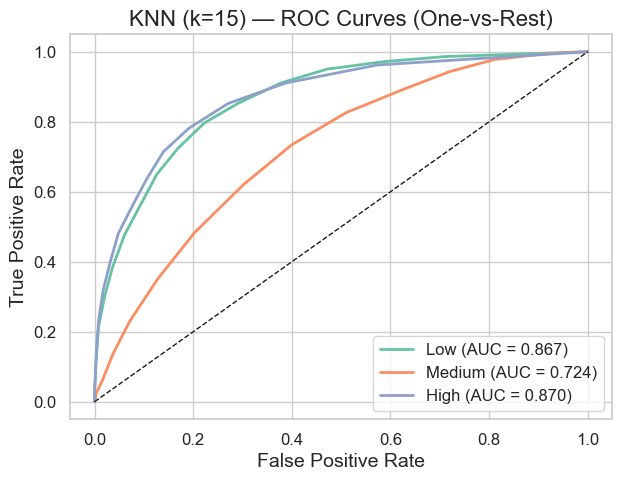

AUC per class:
  Low: 0.8667
  Medium: 0.7242
  High: 0.8702


In [16]:
class_order_knn = list(best_knn.classes_)  # ['High', 'Low', 'Medium']
y_prob_knn = best_knn.predict_proba(X_test_sc)

fig, ax = plt.subplots(figsize=(7, 5))
knn_auc = {}
for i, cls in enumerate(classes):
    idx = class_order_knn.index(cls)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, idx])
    roc_auc = auc(fpr, tpr)
    knn_auc[cls] = roc_auc
    ax.plot(fpr, tpr, color=class_colors[cls], lw=2,
            label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('KNN (k=15) — ROC Curves (One-vs-Rest)')
ax.legend(loc='lower right')
save_plot(fig, 'knn_roc_curve.png')
plt.show()

print('AUC per class:')
for cls, v in knn_auc.items():
    print(f'  {cls}: {v:.4f}')

**KNN ROC discussion:**

KNN (k=15) ROC AUC values:
- **Low AUC = 0.867** — good, but 0.031 lower than Decision Tree (0.898)
- **High AUC = 0.870** — good, and close to Decision Tree (0.883)
- **Medium AUC = 0.724** — 0.065 below Decision Tree (0.789)

The largest gap between DT and KNN is on the Medium class (0.789 vs 0.724).
KNN struggles more with Medium because the soft probability estimates from
k=15 neighbours are noisy in the overlap region between Low and High,
whereas the Decision Tree builds explicit rules that better carve out the Medium space.

All AUC values are still well above 0.5, confirming KNN has real discriminative power,
just consistently weaker than the Decision Tree on this dataset.